In [6]:
from scripts.util import vizualize_intrinsic_channels, apply_mask, pil_to_normalized_tensor, save_intrinsic_channels
from scripts.rgbx_inference import build_rgbx_pipeline, infer_intrinsic_channels, infer_intrinsic_channels_for_dataset

In [8]:
pipe = build_rgbx_pipeline("/home/jsickert/adl4cv/rgb2x/model_cache")

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 5/5 [00:05<00:00,  1.03s/it]


In [4]:
intrinsic_channels = infer_intrinsic_channels(
     "/home/jsickert/adl4cv/DATA/001/MVI_1812/image/1.png", pipe=pipe
)

100%|██████████| 50/50 [00:02<00:00, 22.57it/s]


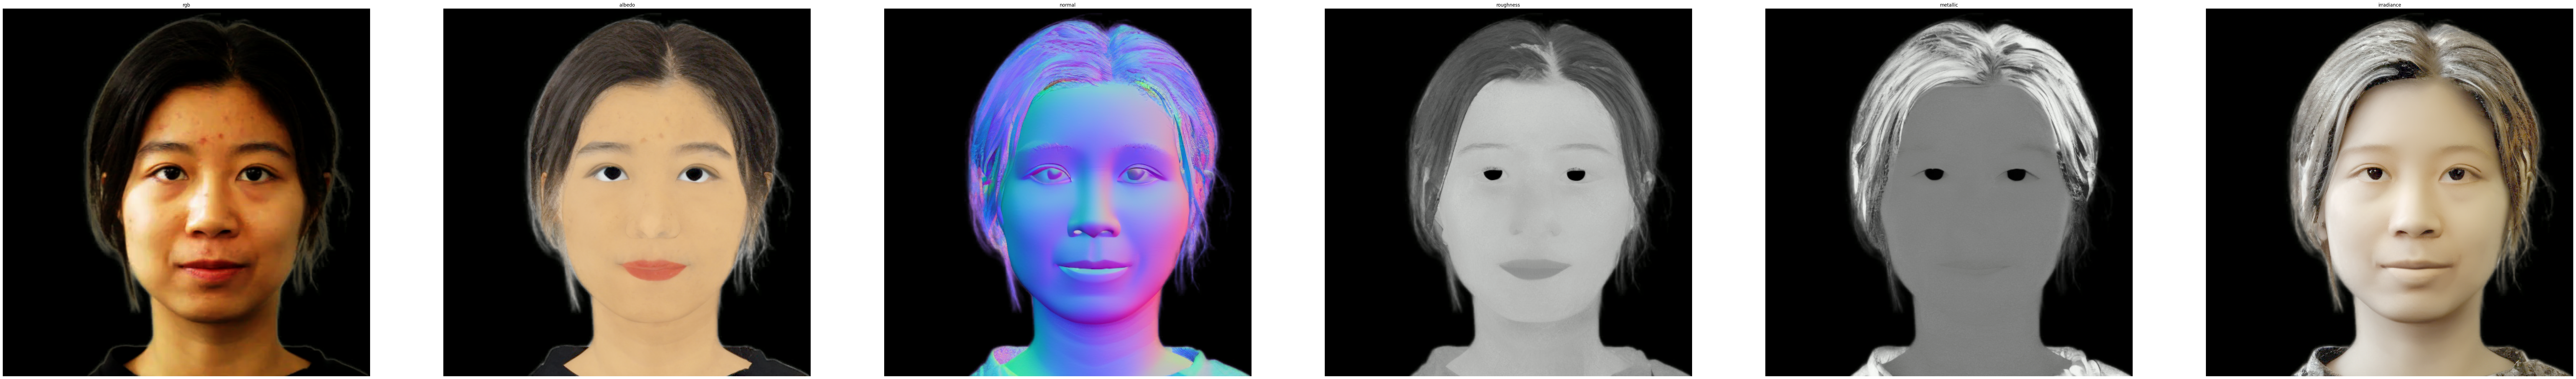

In [4]:
masked_intrinsic_channels = apply_mask(intrinsic_channels, mask_path="/home/jsickert/adl4cv/DATA/001/MVI_1810/mask/1.png")
vizualize_intrinsic_channels(masked_intrinsic_channels)

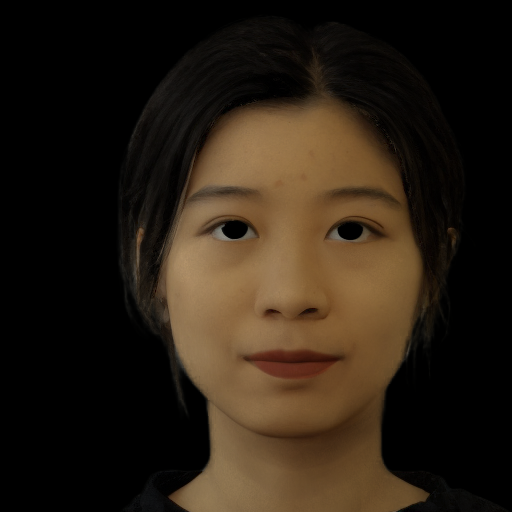

In [5]:
import torchvision

albedo = pil_to_normalized_tensor(masked_intrinsic_channels["albedo"])
irradiance = pil_to_normalized_tensor(masked_intrinsic_channels["irradiance"])
roughness = pil_to_normalized_tensor(masked_intrinsic_channels["roughness"])

diffuse_reconstruction = albedo * irradiance * roughness

torchvision.transforms.functional.to_pil_image(diffuse_reconstruction)

In [5]:
save_intrinsic_channels(
    intrinsic_channels, "1", "/home/jsickert/adl4cv/adl4cv_ws25-26_Relightable-Avatars/experiments/001"
)

In [9]:
for view in ['466', '1779', '1071', '920']:
    intrinsic_channels = infer_intrinsic_channels(
        f"/home/jsickert/adl4cv/DATA/001/MVI_1812/image/{view}.png", pipe=pipe
    )

    save_intrinsic_channels(
        intrinsic_channels, str(view), "/home/jsickert/adl4cv/DATA_rgbx/001/MVI_1812/"
    )

100%|██████████| 50/50 [00:02<00:00, 21.58it/s]
